# Fraud Operations Analysis

## D1 — Load data and quick data quality check

In this section we:
- load the dataset
- inspect structure
- check missing values
- compute the fraud rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("creditcard.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13954, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13954 entries, 0 to 13953
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    13954 non-null  int64  
 1   V1      13954 non-null  float64
 2   V2      13954 non-null  float64
 3   V3      13954 non-null  float64
 4   V4      13954 non-null  float64
 5   V5      13954 non-null  float64
 6   V6      13954 non-null  float64
 7   V7      13954 non-null  float64
 8   V8      13954 non-null  float64
 9   V9      13954 non-null  float64
 10  V10     13954 non-null  float64
 11  V11     13954 non-null  float64
 12  V12     13954 non-null  float64
 13  V13     13954 non-null  float64
 14  V14     13954 non-null  float64
 15  V15     13954 non-null  float64
 16  V16     13954 non-null  float64
 17  V17     13954 non-null  float64
 18  V18     13954 non-null  float64
 19  V19     13954 non-null  float64
 20  V20     13954 non-null  float64
 21  V21     13954 non-null  float64
 22

In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [5]:
fraud_counts = df['Class'].value_counts()

total_rows = len(df)
fraud_count = fraud_counts[1]
fraud_rate = fraud_count / total_rows

print("Total transactions:", total_rows)
print("Fraud transactions:", fraud_count)
print("Fraud rate:", fraud_rate)

Total transactions: 13954
Fraud transactions: 56
Fraud rate: 0.004013186183173284


## D2 — Fraud rate by transaction amount

Fraud transactions may be more common in certain transaction size ranges.  
We analyze fraud rate across transaction amount buckets.

In [6]:
import pandas as pd
df['amount_bucket'] = pd.qcut(df['Amount'], 10)

In [7]:
fraud_by_bucket = (
    df.groupby('amount_bucket')['Class']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={
          'count': 'transactions',
          'sum': 'frauds',
          'mean': 'fraud_rate'
      })
)

fraud_by_bucket

/tmp/ipykernel_197/710821369.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amount_bucket')['Class']


,transactions,frauds,fraud_rate
amount_bucket,,,
"(-0.001, 1.0]",1525,42.0,0.027541
"(1.0, 4.212]",1266,4.0,0.003160
"(4.212, 8.49]",1401,0.0,0.000000
"(8.49, 11.85]",1765,1.0,0.000567
"(11.85, 15.69]",1020,0.0,0.000000
"(15.69, 23.9]",1397,0.0,0.000000
"(23.9, 39.0]",1405,1.0,0.000712
"(39.0, 72.166]",1383,1.0,0.000723
"(72.166, 149.0]",1396,0.0,0.000000


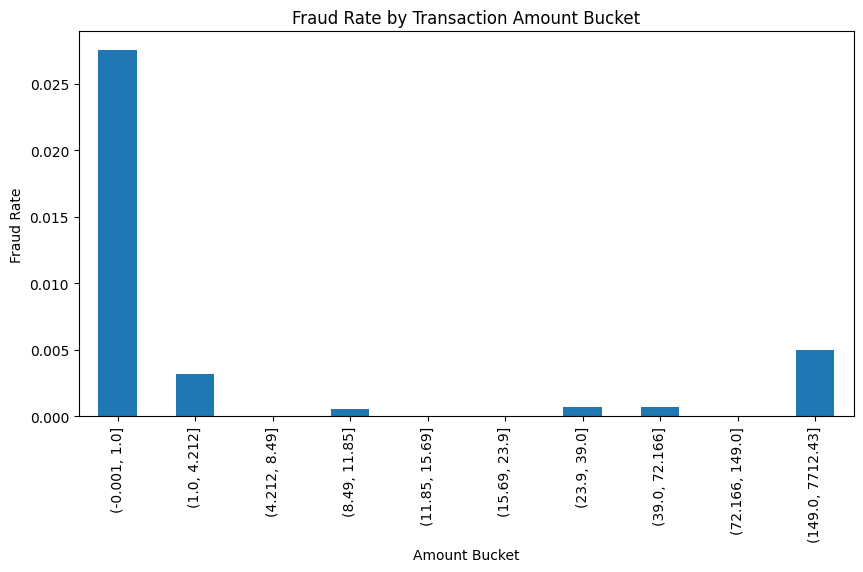

In [8]:
fraud_by_bucket['fraud_rate'].plot(
    kind='bar',
    figsize=(10,5),
    title='Fraud Rate by Transaction Amount Bucket'
)

plt.ylabel("Fraud Rate")
plt.xlabel("Amount Bucket")
plt.show()

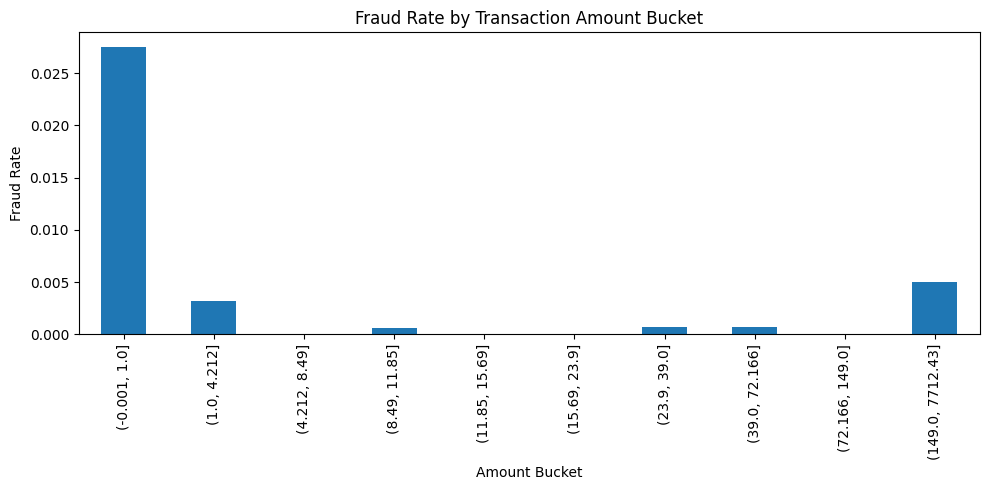

In [9]:
plt.figure(figsize=(10,5))
fraud_by_bucket['fraud_rate'].plot(kind='bar')

plt.title("Fraud Rate by Transaction Amount Bucket")
plt.ylabel("Fraud Rate")
plt.xlabel("Amount Bucket")

plt.tight_layout()
plt.savefig("fraud_rate_by_amount.png")

### Insight

Fraud rate is significantly higher in the smallest transaction amount bucket.

This suggests that fraudulent transactions are more likely to occur at low amounts.  
One possible explanation is that fraudsters attempt small transactions first to test whether a stolen card is active and to avoid triggering fraud detection rules.

Operational implication: monitoring systems may benefit from increased scrutiny of repeated small transactions.

## D3 — Fraud activity by hour

We analyze whether fraud transactions occur more frequently during certain hours.

In [10]:
df['hour'] = (df['Time'] // 3600) % 24

In [11]:
fraud_by_hour = (
    df.groupby('hour')['Class']
      .agg(['count','sum','mean'])
      .rename(columns={
          'count':'transactions',
          'sum':'frauds',
          'mean':'fraud_rate'
      })
)

fraud_by_hour

,transactions,frauds,fraud_rate
hour,,,
0,3963,2.0,0.000505
1,2217,2.0,0.000902
2,1576,21.0,0.013325
3,1821,13.0,0.007139
4,1082,6.0,0.005545
5,1681,11.0,0.006544
6,1613,1.0,0.000620


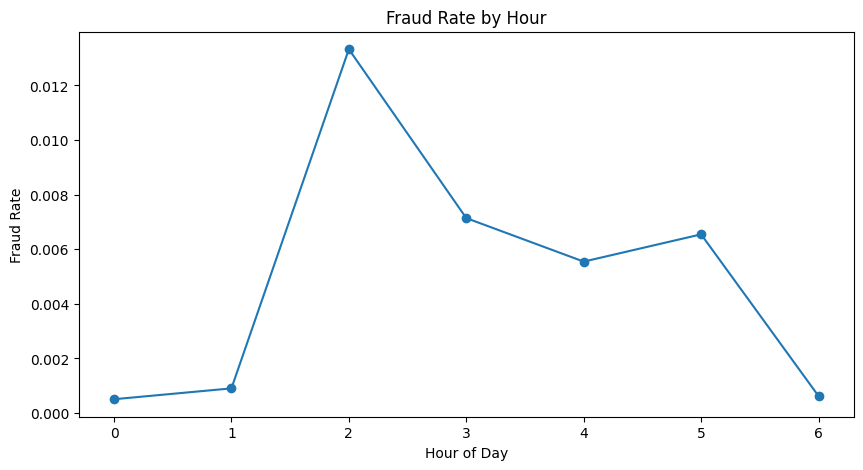

In [12]:
fraud_by_hour['fraud_rate'].plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    title='Fraud Rate by Hour'
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

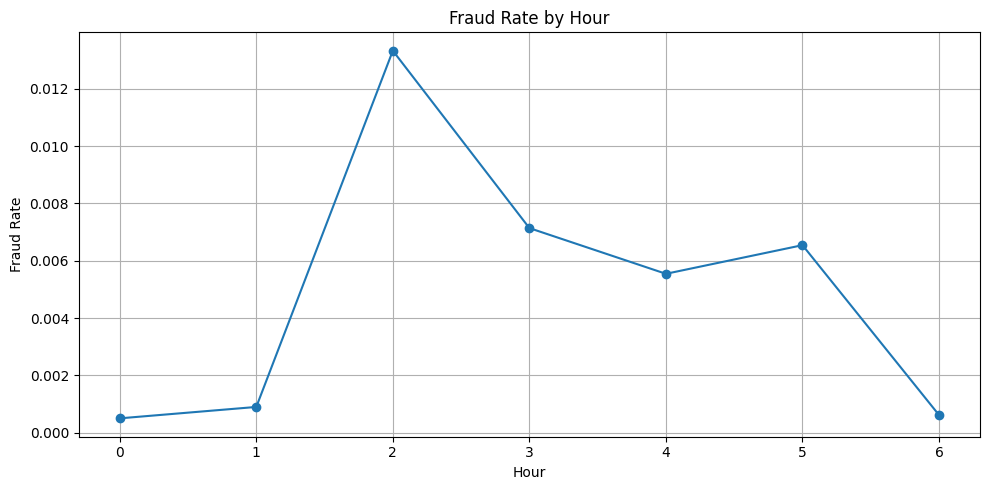

In [13]:
plt.figure(figsize=(10,5))

fraud_by_hour['fraud_rate'].plot(
    kind='line',
    marker='o'
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.grid(True)

plt.tight_layout()
plt.savefig("fraud_rate_by_hour.png")

## D4 — Rapid Transaction Bursts

In this section, we analyze whether fraudulent transactions are more likely to occur in rapid sequences.

This dataset does not include card IDs or real timestamps. Instead, it provides a `Time` column, which represents the number of seconds elapsed since the first transaction in the dataset.

Because of this structure, we analyze the time gap between consecutive transactions in the dataset overall, rather than the time gap between transactions on the same card.

This helps test whether fraud is more concentrated in very short transaction intervals.

Fraudulent transactions tend to occur in rapid succession.
Transactions occurring within short time intervals may indicate automated fraud attempts.

In [18]:
# D4 — Rapid Transaction Bursts

d4 = df.copy()

# sort by time
d4 = d4.sort_values('Time').copy()

# previous transaction time
d4['prev_time'] = d4['Time'].shift(1)

# gap in seconds
d4['gap_seconds'] = d4['Time'] - d4['prev_time']

In [27]:
d4[['Time', 'prev_time', 'gap_seconds', 'Class']].head(10)

,Time,prev_time,gap_seconds,Class
1,0,NaN,NaN,0.0
0,0,0.0,0.0,0.0
3,1,0.0,1.0,0.0
2,1,1.0,0.0,0.0
5,2,1.0,1.0,0.0
4,2,2.0,0.0,0.0
6,4,2.0,2.0,0.0
7,7,4.0,3.0,0.0
8,7,7.0,0.0,0.0
9,9,7.0,2.0,0.0


In [28]:
d4['gap_bucket'] = pd.cut(
    d4['gap_seconds'],
    bins=[-1, 1, 10, 60, float('inf')],
    labels=['under_1_sec', '1_to_10_sec', '10_to_60_sec', '60_plus_sec']
)

In [31]:
burst_summary = (
    d4.dropna(subset=['gap_bucket'])
      .groupby('gap_bucket', observed=False)
      .agg(
          total_transactions=('Class', 'size'),
          fraud_transactions=('Class', 'sum')
      )
      .reset_index()
)

# remove empty buckets
burst_summary = burst_summary[burst_summary['total_transactions'] > 0]

burst_summary['fraud_rate'] = (
    burst_summary['fraud_transactions'] / burst_summary['total_transactions']
)

burst_summary['fraud_rate_pct'] = (burst_summary['fraud_rate'] * 100).round(3)

burst_summary = burst_summary.sort_values('fraud_rate', ascending=False)

burst_summary

,gap_bucket,total_transactions,fraud_transactions,fraud_rate,fraud_rate_pct
1,1_to_10_sec,5116,36.0,0.007037,0.704
2,10_to_60_sec,170,1.0,0.005882,0.588
0,under_1_sec,8667,19.0,0.002192,0.219


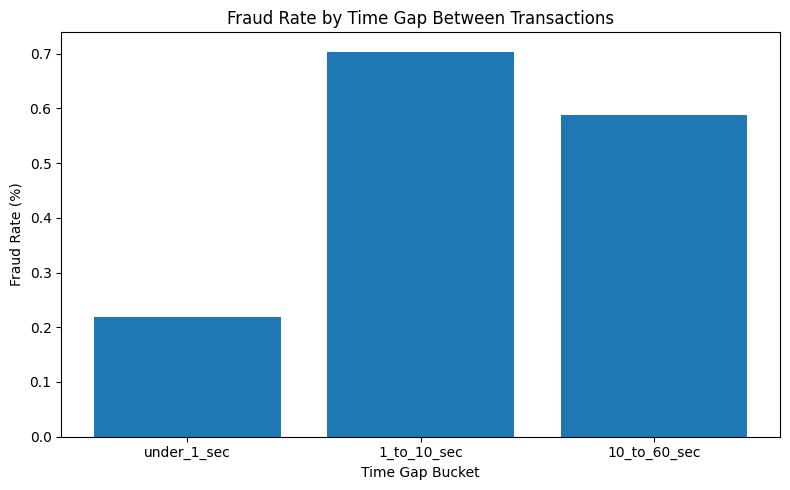

In [34]:
import matplotlib.pyplot as plt

# define correct order
order = ['under_1_sec', '1_to_10_sec', '10_to_60_sec']

plot_df = burst_summary.set_index('gap_bucket').loc[order].reset_index()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['gap_bucket'].astype(str), plot_df['fraud_rate_pct'])
plt.title('Fraud Rate by Time Gap Between Transactions')
plt.xlabel('Time Gap Bucket')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

### D4 Insight

We analyzed the time gap between consecutive transactions using the dataset's Time feature (seconds since the first transaction).

Transactions were grouped into:
- under 1 second
- 1 to 10 seconds
- 10 to 60 seconds

The highest fraud rate was observed in the **1 to 10 seconds** bucket ( about 0.70%), followed by the 10 to 60 seconds bucket (~0.59%). The 1–10 second bucket also contained a large number of transactions (over 5,000), making this pattern both statistically meaningful and operationally relevant.

Interestingly, transactions occurring in under 1 second had a lower fraud rate (about 0.22%), suggesting that fraud is not necessarily associated with the fastest possible activity, but rather with short bursts of activity within a few seconds.

This indicates that fraud attempts may occur in rapid sequences, but not instantaneously, which can be an important signal for fraud detection systems.